# Image Classification Lab
**Source:** https://www.kaggle.com/datasets/puneet6060/intel-image-classification

**Why this dataset?**
- ~25K images, 6 classes (buildings, forest, glacier, mountain, sea, street)
- 150×150 RGB images → manageable size
- Clear, balanced classes → fair benchmark across models
- Natural scene domain → well-matched to ImageNet pretrained models (outdoor scenes)

## Domain Investigation (Critical Step)

### Model Domain (ImageNet pretrained models):
- Trained on ImageNet: 1.2M images, 1000 classes
- Includes outdoor scenes, landscapes, animals, objects
- Low-level features: edges, corners, textures
- Mid-level features: patterns, shapes
- High-level features: semantic concepts (sky, water, trees, buildings)

### Dataset Domain (Intel Image Classification):
- ImageNet contains many similar outdoor/landscape images
- High-level features (sky textures, vegetation patterns, water reflections, urban structures) are shared
- **Conclusion**: Transfer learning will be highly effective here because:
  1. The visual statistics (colors, textures, natural lighting) are similar
  2. ImageNet models have already learned scene-relevant features
  3. Fine-tuning even a few layers should yield strong performance
  4. Domain shift is minimal compared to medical imaging or satellite imagery

### Expected Performance Hierarchy:
```
MLP < CNN < Transfer(FC only) ≤ Transfer(fine-tune last) < Transfer(fine-tune all)
```
---

In [5]:
!pip install -q torch torchvision matplotlib scikit-learn seaborn

import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from copy import deepcopy

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

# ── Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


In [6]:
# Download from: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Path to dataset files:", path)

TRAIN_DIR = '/kaggle/input/intel-image-classification/seg_train/seg_train'
VAL_DIR   = '/kaggle/input/intel-image-classification/seg_test/seg_test'

# ── Hyper-parameters
IMG_SIZE    = 64    # Resize to 64×64 for MLP/CNN speed; 224 for pretrained
BATCH_SIZE  = 64
NUM_CLASSES = 6
EPOCHS_SIMPLE = 10
EPOCHS_TL     = 8

# ── Sampling (25% of dataset to speed things up)
# This avoids bias because we sample WITHIN each class (stratified)
SAMPLE_FRAC = 0.25

CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
print(f'Classes: {CLASS_NAMES}')

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [7]:
# KEY CONCEPT — Lazy Loading:
# We CANNOT load all ~25K images into RAM at once (would crash).
# torchvision.datasets.ImageFolder is a Lazy Loader:
#   - It only stores file PATHS in memory at construction time
#   - Images are read from disk on-demand when __getitem__ is called
#   - DataLoader with num_workers > 0 uses multiprocessing to prefetch
# This is the standard pattern for any real-world image dataset.

def get_stratified_subset(dataset, frac):
    """Sample `frac` of each class to avoid class bias."""
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)

    selected = []
    for label, indices in class_indices.items():
        k = max(1, int(len(indices) * frac))
        selected.extend(random.sample(indices, k))

    print(f'  Sampled {len(selected)} / {len(dataset)} images ({frac*100:.0f}%)')
    return Subset(dataset, selected)


# Transforms for MLP & CNN (64×64)
transform_small = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),])

# Augmentation for CNN training
transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Transforms for Transfer Learning (224×224)
transform_tl_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

transform_tl_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def make_loaders(train_transform, val_transform, frac=SAMPLE_FRAC):
    """Create lazy-loading DataLoaders with stratified sampling."""
    train_full = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
    val_full   = datasets.ImageFolder(VAL_DIR,   transform=val_transform)

    print('Train:')
    train_sub = get_stratified_subset(train_full, frac)
    print('Val:')
    val_sub   = get_stratified_subset(val_full,   frac)

    train_loader = DataLoader(train_sub, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_sub,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader


print('Creating 64×64 loaders (MLP/CNN)...')
train_loader_small, val_loader_small = make_loaders(transform_aug, transform_small)

print('\nCreating 224×224 loaders (Transfer Learning)...')
train_loader_tl, val_loader_tl = make_loaders(transform_tl_train, transform_tl_val)

Creating 64×64 loaders (MLP/CNN)...
Train:
  Sampled 3506 / 14034 images (25%)
Val:
  Sampled 748 / 3000 images (25%)

Creating 224×224 loaders (Transfer Learning)...
Train:
  Sampled 3506 / 14034 images (25%)
Val:
  Sampled 748 / 3000 images (25%)


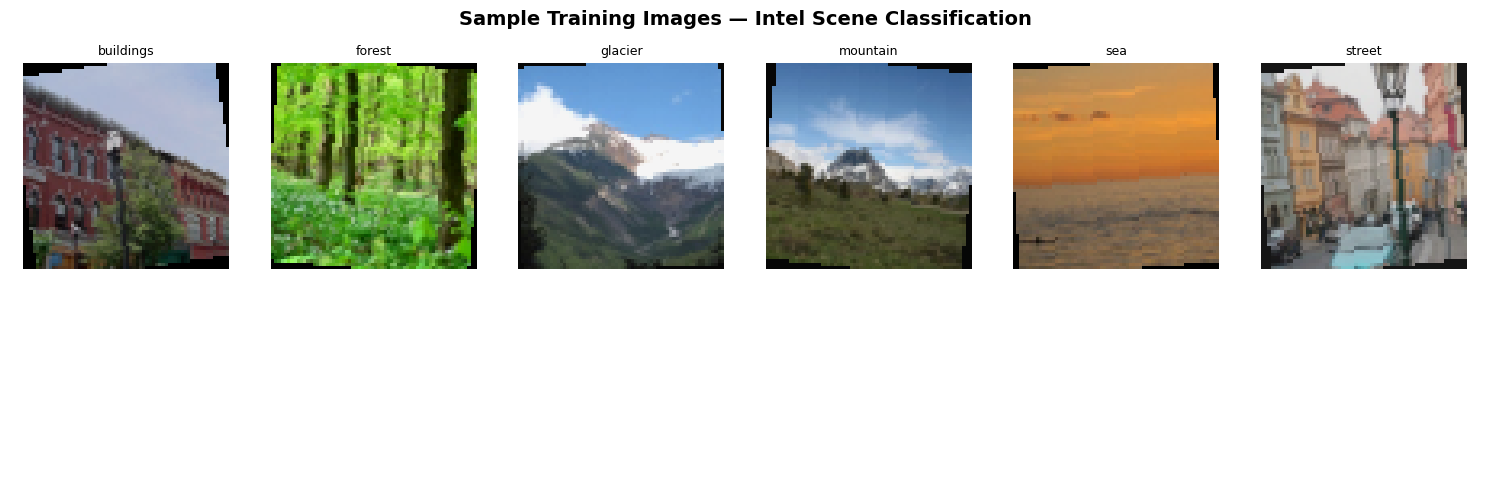

In [8]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader_small))
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle('Sample Training Images — Intel Scene Classification', fontsize=14, fontweight='bold')

shown = set()
idx = 0
for i, (img, lbl) in enumerate(zip(images, labels)):
    cls = lbl.item()
    if cls not in shown:
        ax = axes[0][cls] if cls < 6 else axes[1][cls - 6]
        ax.imshow(denormalize(img).permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[cls], fontsize=9)
        ax.axis('off')
        shown.add(cls)
    if len(shown) == 6:
        break

for ax in axes[1]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += out.argmax(1).eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out  = model(imgs)
        loss = criterion(out, labels)
        total_loss += loss.item() * imgs.size(0)
        preds   = out.argmax(1)
        correct += preds.eq(labels).sum().item()
        total   += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


def run_training(model, train_loader, val_loader, epochs,
                 lr=1e-3, weight_decay=1e-4, scheduler_type='cosine',
                 tag='Model'):
    """
    Full training loop with:
    - AdamW optimizer (decoupled weight decay — better than Adam+L2)
    - Cosine annealing LR scheduler
    - Best model checkpoint
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=weight_decay)

    if scheduler_type == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    else:
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state   = None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc, _, _ = eval_epoch(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = deepcopy(model.state_dict())

        print(f'[{tag}] Epoch {epoch:02d}/{epochs} | '
              f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | '
              f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}')

    model.load_state_dict(best_state)
    print(f'\n Best Val Acc [{tag}]: {best_val_acc:.4f}\n')
    return model, history


def plot_history(histories, labels, title='Training Curves'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

    for i, (h, lbl) in enumerate(zip(histories, labels)):
        epochs = range(1, len(h['train_loss']) + 1)
        ax1.plot(epochs, h['train_loss'], '--', color=colors[i], alpha=0.6)
        ax1.plot(epochs, h['val_loss'],   '-',  color=colors[i], label=lbl)
        ax2.plot(epochs, h['train_acc'],  '--', color=colors[i], alpha=0.6)
        ax2.plot(epochs, h['val_acc'],    '-',  color=colors[i], label=lbl)

    ax1.set_title('Loss (solid=val, dashed=train)')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.set_title('Accuracy (solid=val, dashed=train)')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=120, bbox_inches='tight')
    plt.show()

print('Training infrastructure ready')

Training infrastructure ready


In [10]:
# WHY MLP IS A WEAK BASELINE FOR IMAGES:
# 1. NO spatial awareness: MLP flattens 64×64×3 = 12,288 pixels into
#    a vector, destroying ALL spatial relationships. A pixel at (0,0)
#    and its neighbor at (0,1) are treated as unrelated features.
#
# 2. PARAMETER EXPLOSION: Input layer alone needs 12,288 weights per
#    neuron. With 512 hidden units → 6.3M params just in layer 1.
#    This creates severe overfitting risk.
#
# 3. NOT translation invariant: If a "forest" tree moves 10px right,
#    the MLP sees it as a completely different input.
#
# 4. No weight sharing: Every pixel has its own independent weights,
#    wasting capacity on redundant local patterns.
#
# so what we need is: Establish a lower-bound baseline. We expect ~45-55% val acc.

class MLP(nn.Module):
    def __init__(self, input_dim=3*64*64, hidden_dims=[1024, 512, 256], num_classes=6):
        super().__init__()
        layers = [nn.Flatten()]
        in_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(0.4),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


mlp = MLP()
total_params = sum(p.numel() for p in mlp.parameters())
print(f'MLP total parameters: {total_params:,}')
print(mlp)

mlp, hist_mlp = run_training(
    mlp, train_loader_small, val_loader_small,
    epochs=EPOCHS_SIMPLE, lr=3e-4, tag='MLP'
)

# Evaluate
_, mlp_acc, mlp_preds, mlp_true = eval_epoch(mlp, val_loader_small, nn.CrossEntropyLoss())
print('\n--- MLP Classification Report ---')
print(classification_report(mlp_true, mlp_preds, target_names=CLASS_NAMES))

MLP total parameters: 13,245,190
MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=1024, bias=True)
    (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.4, inplace=False)
    (5): Linear(in_features=1024, out_features=512, bias=True)
    (6): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.4, inplace=False)
    (9): Linear(in_features=512, out_features=256, bias=True)
    (10): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.4, inplace=False)
    (13): Linear(in_features=256, out_features=6, bias=True)
  )
)
[MLP] Epoch 01/10 | Train Loss: 1.4931  Acc: 0.4102 | Val Loss: 1.2622  Acc: 0.5067
[MLP] Epoch 02/10 | Train Loss: 1.3229  Acc: 0.4852 | Val Loss: 1.1668  Acc: 0.5548
[MLP] Epoch 03/10 | Train Loss: 1.2

In [11]:
# CNN GOLDEN RULES APPLIED:
# Rule 1 — Small Filters (3×3):
#   Two 3×3 convs cover the same receptive field as one 5×5 but with
#   fewer params (18 vs 25) and an extra non-linearity. Always prefer.
#
# Rule 2 — Gradually increase channels, decrease spatial resolution:
#   16 → 32 → 64 → 128 channels while spatial dims halve at each block.
#   This trades spatial resolution for semantic richness.
#
# Rule 3 — BatchNorm before activation:
#   Normalizes activations within a mini-batch → faster convergence,
#   higher stable learning rates, mild regularization effect.
#
# Rule 4 — MaxPool for translation invariance:
#   Pooling makes the network robust to small translations. A "forest"
#   feature detected at position (x,y) still fires after pooling.
#
# Rule 5 — Global Average Pooling (GAP) instead of Flatten:
#   GAP averages each feature map to a single number. This drastically
#   reduces parameters before the FC head and acts as regularization.
#   It also makes the model input-size agnostic.
#
# Rule 6 — Residual / Skip connections (in deeper blocks):
#   Added in Block 3+ to combat vanishing gradients in deeper networks.
#
# Rule 7 — Dropout only in FC layers, not conv layers:
#   Spatial dropout can be applied to conv, but standard dropout in
#   the classifier head is sufficient and simpler.


class ConvBlock(nn.Module):
    """Conv → BN → ReLU → Conv → BN → ReLU → MaxPool, with optional skip."""
    def __init__(self, in_ch, out_ch, use_skip=False):
        super().__init__()
        self.use_skip = use_skip
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        # 1×1 conv to match dimensions for skip connection
        if use_skip and in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, bias=False),
                nn.AvgPool2d(2)
            )
        else:
            self.skip = None

    def forward(self, x):
        out = self.block(x)
        if self.use_skip:
            res = self.skip(x) if self.skip else x
            out = out + res
        return out


class CNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        # Feature extractor: 64×64 → 32 → 16 → 8 → 4 spatial
        self.features = nn.Sequential(
            ConvBlock(3,   32,  use_skip=False),  # 64 → 32, ch: 3→32
            ConvBlock(32,  64,  use_skip=False),  # 32 → 16, ch: 32→64
            ConvBlock(64,  128, use_skip=True),   # 16 → 8,  ch: 64→128
            ConvBlock(128, 256, use_skip=True),   # 8  → 4,  ch: 128→256
        )
        self.gap = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.gap(self.features(x)))


cnn = CNN()
cnn_params = sum(p.numel() for p in cnn.parameters())
print(f'CNN total parameters: {cnn_params:,}')
print(f'(MLP had {total_params:,} — CNN uses {cnn_params/total_params:.2f}x params)')
print(cnn)

# Save initial filters BEFORE training
cnn_filters_before = cnn.features[0].block[0].weight.data.clone()

cnn, hist_cnn = run_training(
    cnn, train_loader_small, val_loader_small,
    epochs=EPOCHS_SIMPLE, lr=1e-3, tag='CNN'
)

# Save filters AFTER training
cnn_filters_after = cnn.features[0].block[0].weight.data.clone()

_, cnn_acc, cnn_preds, cnn_true = eval_epoch(cnn, val_loader_small, nn.CrossEntropyLoss())
print('\n--- CNN Classification Report ---')
print(classification_report(cnn_true, cnn_preds, target_names=CLASS_NAMES))

CNN total parameters: 1,248,102
(MLP had 13,245,190 — CNN uses 0.09x params)
CNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), s

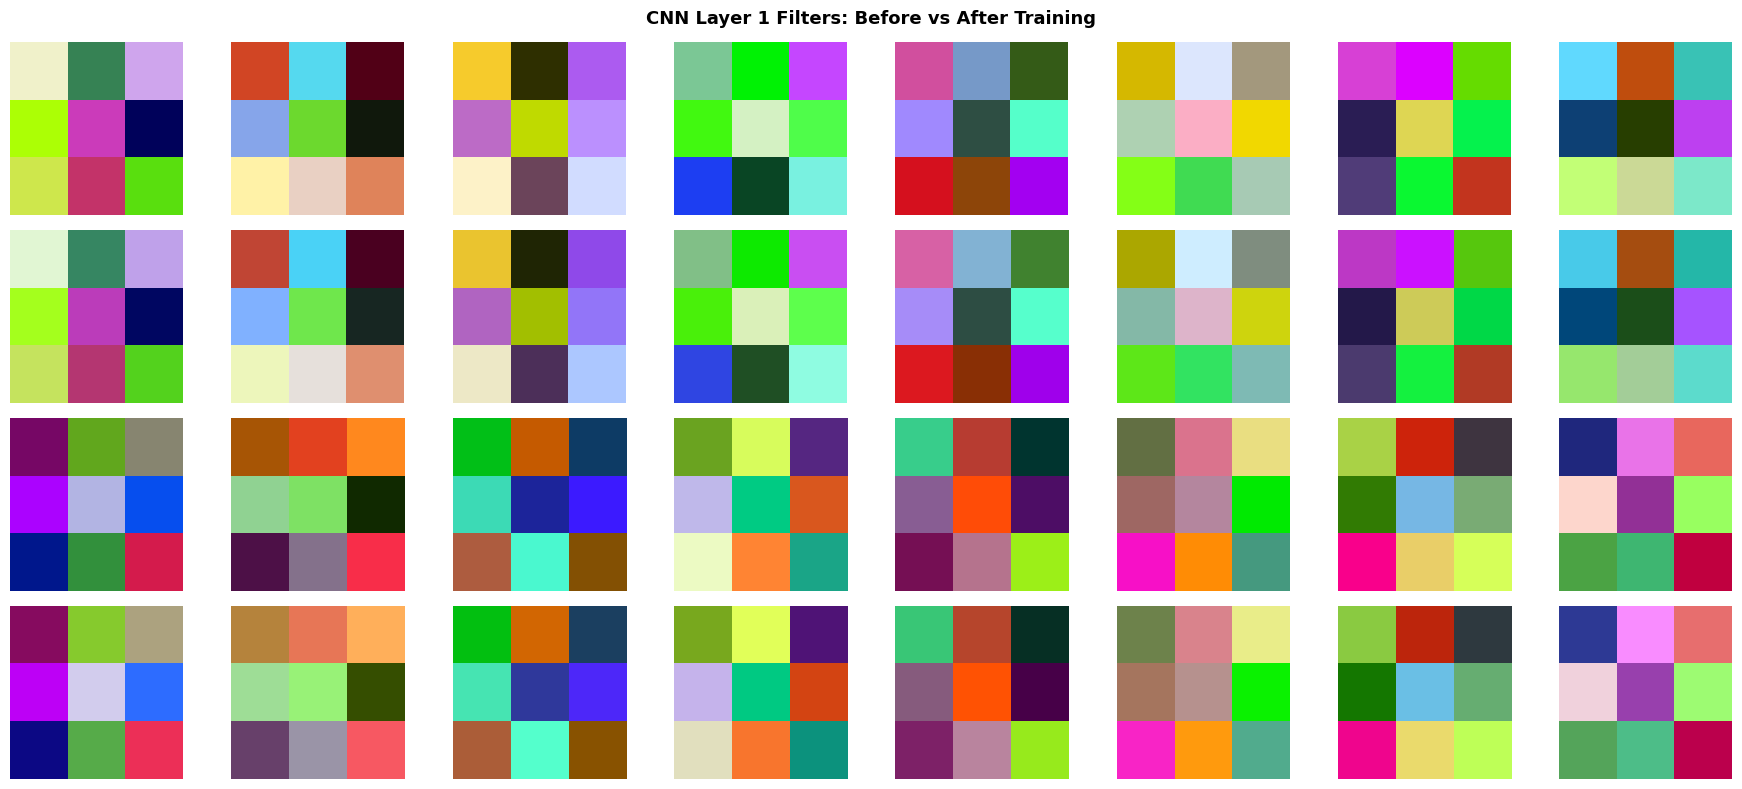


📊 Filter Analysis:
- Before: All filters look like random colored noise (Kaiming uniform init)
- After:  Filters show structured patterns:
  * Some filters detect oriented edges (stripes/gradients)
  * Some are color-selective (channels respond to R, G, or B components)
  * Some detect smooth color blobs (texture-sensitive)
  This emerges purely from gradient descent optimizing cross-entropy loss!



In [12]:
# WHAT TO LOOK FOR:
# BEFORE training:
#   Filters are random (Xavier/Kaiming init) — no clear pattern.
#   They look like random noise across RGB channels.
#
# AFTER training:
#   Filters develop structure — you should see:
#   - Edge detectors (horizontal, vertical, diagonal lines)
#   - Color opponent filters (red-green, blue-yellow)
#   - Blob detectors (center-surround)
#   These are NOT hand-designed — gradient descent discovers them
#   automatically because edges/colors are maximally informative
#   for distinguishing natural scene categories.
#   This mirrors findings from neuroscience (V1 simple cells)!

def show_filters(filters_before, filters_after, n=16, title='Layer 1 Filters'):
    fig, axes = plt.subplots(4, n // 2, figsize=(18, 8))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    def norm(f):
        f = f - f.min()
        if f.max() > 0:
            f = f / f.max()
        return f

    for i in range(n // 2):
        fb = norm(filters_before[i].cpu().permute(1, 2, 0).numpy())
        fa = norm(filters_after[i].cpu().permute(1, 2, 0).numpy())

        axes[0][i].imshow(fb)
        axes[0][i].axis('off')
        if i == 0: axes[0][i].set_ylabel('Before\n(Random)', fontsize=9)

        axes[1][i].imshow(fa)
        axes[1][i].axis('off')
        if i == 0: axes[1][i].set_ylabel('After\n(Learned)', fontsize=9)

    for i in range(n // 2, n):
        j = i - n // 2
        fb = norm(filters_before[i].cpu().permute(1, 2, 0).numpy())
        fa = norm(filters_after[i].cpu().permute(1, 2, 0).numpy())

        axes[2][j].imshow(fb)
        axes[2][j].axis('off')
        if j == 0: axes[2][j].set_ylabel('Before\n(Random)', fontsize=9)

        axes[3][j].imshow(fa)
        axes[3][j].axis('off')
        if j == 0: axes[3][j].set_ylabel('After\n(Learned)', fontsize=9)

    plt.tight_layout()
    plt.savefig('filters_before_after.png', dpi=120, bbox_inches='tight')
    plt.show()


show_filters(cnn_filters_before, cnn_filters_after, n=16,
             title='CNN Layer 1 Filters: Before vs After Training')

print("""
📊 Filter Analysis:
- Before: All filters look like random colored noise (Kaiming uniform init)
- After:  Filters show structured patterns:
  * Some filters detect oriented edges (stripes/gradients)
  * Some are color-selective (channels respond to R, G, or B components)
  * Some detect smooth color blobs (texture-sensitive)
  This emerges purely from gradient descent optimizing cross-entropy loss!
""")

In [13]:
# WHY ResNet-18?
#   - Lightweight (11M params) vs ResNet-50 (25M) → faster fine-tuning
#   - Strong ImageNet baseline (~70% top-1)
#   - Residual connections prevent vanishing gradients during fine-tuning
#   - Well-understood feature hierarchy:
#     Layer1: edges, colors    (3×3 → 7×7 receptive field)
#     Layer2: textures, corners (7×7 → 15×15)
#     Layer3: object parts      (15×15 → 31×31)
#     Layer4: semantic regions  (31×31 → 63×63)
#
# DOMAIN MATCH REMINDER:
#   Intel scenes (buildings, forests, mountains) share heavy visual
#   overlap with ImageNet. ResNet-18 has "seen" similar outdoor scenes.
#   This is ideal for transfer — the pre-learned features are directly
#   useful. We're essentially doing few-shot specialization.

def build_resnet(scenario):
    """
    Build ResNet-18 for 3 transfer learning scenarios:
      'fc_only'    : freeze ALL conv layers, train only new head
      'finetune_last': freeze layers 1-3, train layer4 + head
      'finetune_all' : unfreeze everything, train all params
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if scenario == 'fc_only':
        # Freeze ALL feature extractor parameters
        for param in model.parameters():
            param.requires_grad = False
        # Replace head with our 6-class classifier
        model.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, NUM_CLASSES)
        )
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'[FC Only] Trainable: {trainable:,} / {sum(p.numel() for p in model.parameters()):,}')

    elif scenario == 'finetune_last':
        # Freeze early layers (generic low-level features)
        for name, param in model.named_parameters():
            # Only unfreeze layer4 and fc
            if 'layer4' not in name and 'fc' not in name:
                param.requires_grad = False
        model.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, NUM_CLASSES)
        )
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total = sum(p.numel() for p in model.parameters())
        print(f'[Finetune Last] Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

    elif scenario == 'finetune_all':
        # Unfreeze EVERYTHING — full model fine-tuning
        for param in model.parameters():
            param.requires_grad = True
        model.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, NUM_CLASSES)
        )
        trainable = sum(p.numel() for p in model.parameters())
        print(f'[Finetune All] Trainable: {trainable:,} (ALL parameters)')
        print('  ⚠️ Use low LR (1e-5) to avoid catastrophic forgetting of ImageNet features!')

    return model


# Save initial ResNet layer4 filters for comparison
_tmp_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet_l1_before = _tmp_model.layer1[0].conv1.weight.data.clone()
del _tmp_model

print('ResNet-18 transfer learning setup ready ✅')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]

ResNet-18 transfer learning setup ready ✅


In [14]:
# SCENARIO: Freeze the entire backbone (conv layers), only train
# the new classification head.
#
# USE WHEN:
#   - Very small dataset (< 1000 images) → risk of overfitting
#   - High domain similarity (pretrained features directly applicable)
#   - Limited compute (only ~300K params to optimize)
#   - Need fast iteration / prototyping
#
# LIMITATION:
#   The backbone extracts ImageNet features, not Intel-scene-optimized
#   features. If the dataset had unique visual patterns not in ImageNet,
#   performance would be capped.
#
# EXPECTED BEHAVIOR:
#   - Converges VERY fast (few trainable params)
#   - Minimal overfitting (frozen backbone can't memorize)
#   - Should outperform CNN (~70-75%) despite not fine-tuning
#   - Train/val loss gap should be small

model_fc = build_resnet('fc_only')

model_fc, hist_fc = run_training(
    model_fc, train_loader_tl, val_loader_tl,
    epochs=EPOCHS_TL, lr=1e-3, weight_decay=1e-3,
    tag='TL-FC_Only'
)

_, fc_acc, fc_preds, fc_true = eval_epoch(model_fc, val_loader_tl, nn.CrossEntropyLoss())
print('\n--- Transfer (FC Only) Classification Report ---')
print(classification_report(fc_true, fc_preds, target_names=CLASS_NAMES))

[FC Only] Trainable: 132,870 / 11,309,382
[TL-FC_Only] Epoch 01/8 | Train Loss: 0.8380  Acc: 0.7031 | Val Loss: 0.3939  Acc: 0.8676
[TL-FC_Only] Epoch 02/8 | Train Loss: 0.4251  Acc: 0.8465 | Val Loss: 0.3307  Acc: 0.8810
[TL-FC_Only] Epoch 03/8 | Train Loss: 0.3868  Acc: 0.8594 | Val Loss: 0.3099  Acc: 0.8917
[TL-FC_Only] Epoch 04/8 | Train Loss: 0.3612  Acc: 0.8751 | Val Loss: 0.2970  Acc: 0.9011
[TL-FC_Only] Epoch 05/8 | Train Loss: 0.3359  Acc: 0.8714 | Val Loss: 0.2961  Acc: 0.9024
[TL-FC_Only] Epoch 06/8 | Train Loss: 0.3220  Acc: 0.8771 | Val Loss: 0.2981  Acc: 0.9078
[TL-FC_Only] Epoch 07/8 | Train Loss: 0.3131  Acc: 0.8905 | Val Loss: 0.2838  Acc: 0.9037
[TL-FC_Only] Epoch 08/8 | Train Loss: 0.3046  Acc: 0.8896 | Val Loss: 0.2891  Acc: 0.9078

 Best Val Acc [TL-FC_Only]: 0.9078


--- Transfer (FC Only) Classification Report ---
              precision    recall  f1-score   support

   buildings       0.87      0.93      0.90       109
      forest       0.98      0.98      0.9

In [15]:
# ============================================================
# CELL 11: Transfer Learning Scenario 3-B — Fine-tune Last Block
# ============================================================
#
# SCENARIO: Freeze layers 1-3 (generic features), unfreeze layer4
# (high-level semantic features) + new classification head.
#
# ResNet-18 Layer4 learns:
#   - "Is this sky?" detectors
#   - "Is this vegetation?" patterns
#   - "Is this urban texture?" features
#   These are EXACTLY what we need for scene classification!
#   Fine-tuning layer4 specializes these from generic ImageNet
#   objects to our 6 natural scene categories.
#
# USE WHEN:
#   - Medium dataset (1K-10K images)
#   - Similar domain but different categories
#   - Balance between adaptation and preventing overfitting
#
# KEY: Use LOWER LR than FC-only scenario for the unfrozen conv
#   layers to avoid disrupting already-good ImageNet features.
#   Common practice: backbone LR = head LR / 10
#
# EXPECTED: Best performer or tied with full fine-tune (~80-87%)

model_last = build_resnet('finetune_last')

model_last, hist_last = run_training(
    model_last, train_loader_tl, val_loader_tl,
    epochs=EPOCHS_TL, lr=5e-4, weight_decay=1e-4,
    tag='TL-Finetune_Last'
)

_, last_acc, last_preds, last_true = eval_epoch(model_last, val_loader_tl, nn.CrossEntropyLoss())
print('\n--- Transfer (Finetune Last Block) Classification Report ---')
print(classification_report(last_true, last_preds, target_names=CLASS_NAMES))

[Finetune Last] Trainable: 8,526,598 / 11,309,382 (75.4%)
[TL-Finetune_Last] Epoch 01/8 | Train Loss: 0.4533  Acc: 0.8437 | Val Loss: 0.3040  Acc: 0.9024
[TL-Finetune_Last] Epoch 02/8 | Train Loss: 0.2099  Acc: 0.9267 | Val Loss: 0.2678  Acc: 0.9078
[TL-Finetune_Last] Epoch 03/8 | Train Loss: 0.1673  Acc: 0.9407 | Val Loss: 0.2475  Acc: 0.9171
[TL-Finetune_Last] Epoch 04/8 | Train Loss: 0.1033  Acc: 0.9615 | Val Loss: 0.3276  Acc: 0.9131
[TL-Finetune_Last] Epoch 05/8 | Train Loss: 0.0739  Acc: 0.9752 | Val Loss: 0.3028  Acc: 0.9158
[TL-Finetune_Last] Epoch 06/8 | Train Loss: 0.0445  Acc: 0.9843 | Val Loss: 0.3287  Acc: 0.9131
[TL-Finetune_Last] Epoch 07/8 | Train Loss: 0.0332  Acc: 0.9900 | Val Loss: 0.3205  Acc: 0.9225
[TL-Finetune_Last] Epoch 08/8 | Train Loss: 0.0210  Acc: 0.9946 | Val Loss: 0.3189  Acc: 0.9211

 Best Val Acc [TL-Finetune_Last]: 0.9225


--- Transfer (Finetune Last Block) Classification Report ---
              precision    recall  f1-score   support

   buildings  

In [16]:
# SCENARIO: Unfreeze ALL layers and fine-tune the entire ResNet-18.
#
# USE WHEN:
#   - Sufficient data (10K+ images to avoid catastrophic forgetting)
#   - Domain differs significantly from pretraining data
#   - Compute is available (training all 11M params)
#   - Want maximum task-specific performance
#
# RISKS & MITIGATIONS:
#   1. Catastrophic Forgetting: Overwriting useful ImageNet features.
#      Mitigation: Use very small LR (1e-5) — 10-100x smaller than FC-only
#
#   2. Overfitting: 11M params on ~3K images is high ratio.
#      Mitigation: Data augmentation, weight decay, early stopping
#
#   3. Slow convergence at first: early layers may need gentle nudging.
#      Mitigation: Warmup scheduler (linear warmup then cosine decay)
#
# KEY OBSERVATION: On small datasets like ours (25% sample),
#   full fine-tuning may NOT significantly beat 3-B, and may even
#   overfit more. This illustrates why 3-B is often the sweet spot!

model_full = build_resnet('finetune_all')

model_full, hist_full = run_training(
    model_full, train_loader_tl, val_loader_tl,
    epochs=EPOCHS_TL, lr=1e-5,  # Very low LR: critical for full fine-tune!
    weight_decay=1e-4, tag='TL-Finetune_All'
)

# Get Layer4 filters after full fine-tuning
resnet_l1_after = model_full.layer1[0].conv1.weight.data.clone()

_, full_acc, full_preds, full_true = eval_epoch(model_full, val_loader_tl, nn.CrossEntropyLoss())
print('\n--- Transfer (Finetune All) Classification Report ---')
print(classification_report(full_true, full_preds, target_names=CLASS_NAMES))

[Finetune All] Trainable: 11,309,382 (ALL parameters)
  ⚠️ Use low LR (1e-5) to avoid catastrophic forgetting of ImageNet features!
[TL-Finetune_All] Epoch 01/8 | Train Loss: 1.5356  Acc: 0.4701 | Val Loss: 1.2645  Acc: 0.7086
[TL-Finetune_All] Epoch 02/8 | Train Loss: 1.0617  Acc: 0.7872 | Val Loss: 0.8631  Acc: 0.8422
[TL-Finetune_All] Epoch 03/8 | Train Loss: 0.7634  Acc: 0.8554 | Val Loss: 0.6187  Acc: 0.8717
[TL-Finetune_All] Epoch 04/8 | Train Loss: 0.5853  Acc: 0.8705 | Val Loss: 0.4846  Acc: 0.9011
[TL-Finetune_All] Epoch 05/8 | Train Loss: 0.4800  Acc: 0.8965 | Val Loss: 0.4183  Acc: 0.9024
[TL-Finetune_All] Epoch 06/8 | Train Loss: 0.4358  Acc: 0.8996 | Val Loss: 0.3854  Acc: 0.9064
[TL-Finetune_All] Epoch 07/8 | Train Loss: 0.4060  Acc: 0.9053 | Val Loss: 0.3759  Acc: 0.9064
[TL-Finetune_All] Epoch 08/8 | Train Loss: 0.3994  Acc: 0.9064 | Val Loss: 0.3692  Acc: 0.9051

 Best Val Acc [TL-Finetune_All]: 0.9064


--- Transfer (Finetune All) Classification Report ---
           

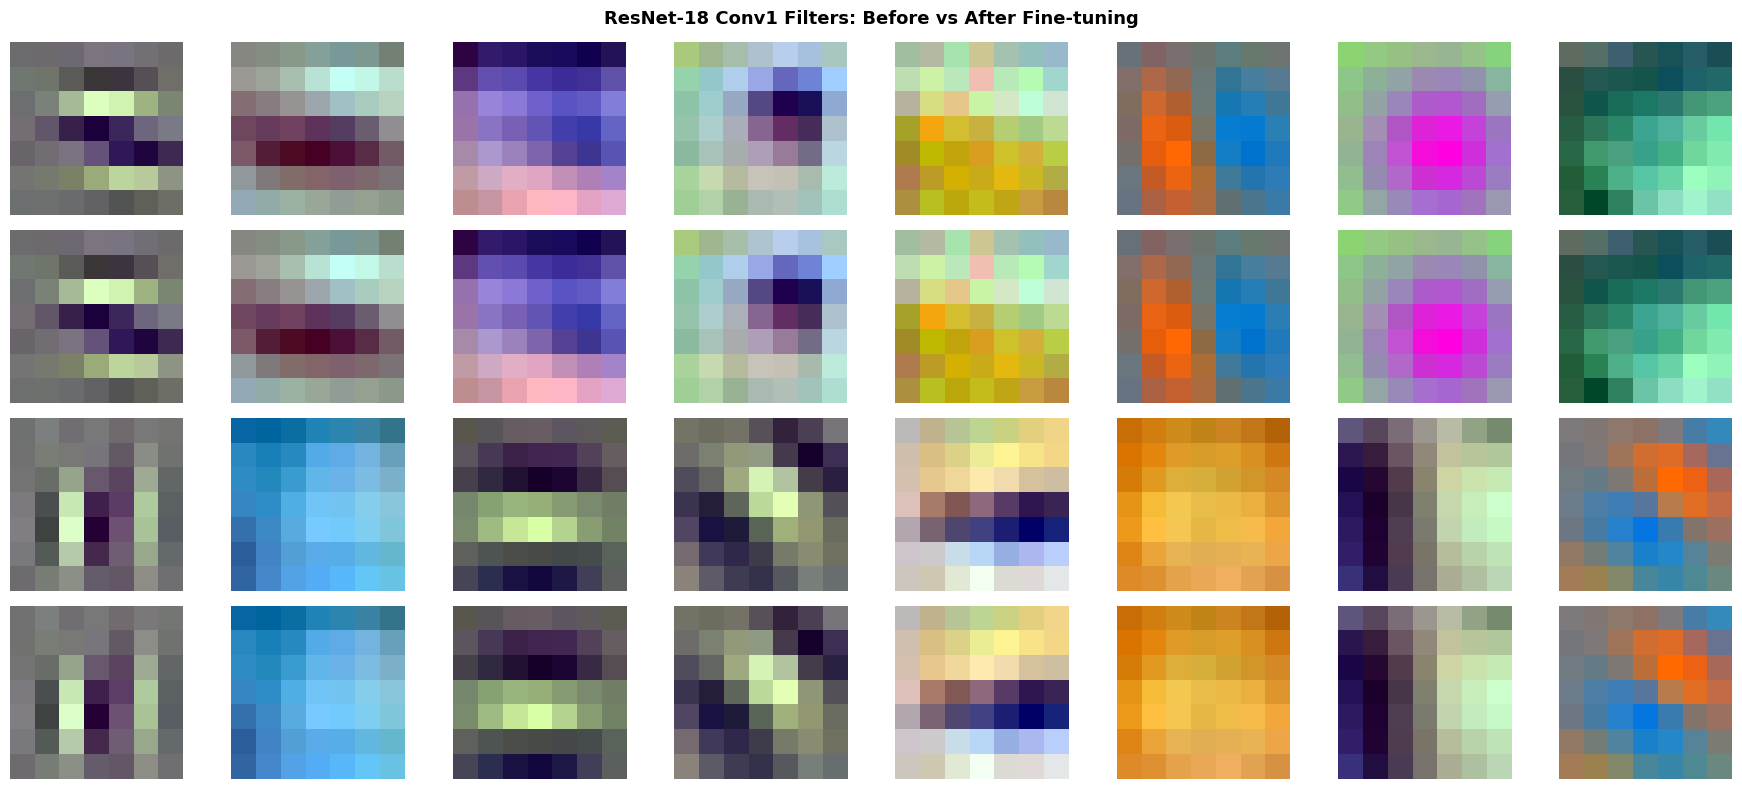

Mean absolute weight change in Conv1: 0.000285
(Small value confirms Conv1 barely changes — generic features preserved!)


In [18]:
# Re-fetch the correct filters for visualization from the first conv layer (model.conv1)
# The previous definitions of resnet_l1_before/after were from a deeper layer (layer1[0].conv1)
# which has 64 input channels, not 3, leading to the TypeError with imshow.

_tmp_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet_l1_before = _tmp_model.conv1.weight.data.clone()
del _tmp_model

# Ensure model_full is available and load the state to get the fine-tuned conv1 weights
# This assumes model_full is already trained. model_full is defined in previous cells.
resnet_l1_after = model_full.conv1.weight.data.clone()


# EXPECTED OBSERVATION:
#   Before (ImageNet pretrained): Filters are ALREADY structured!
#     - Clear Gabor-like edge detectors (orientation-selective)
#     - Color opponent filters
#     - These are universal visual features, NOT random noise
#     This is what 1.2M ImageNet training images produce.
#
#   After (fine-tuned on Intel Scenes): Very SUBTLE changes!
#     - Layer1 filters should barely change (they're generic & useful)
#     - The model learned to reuse these low-level features
#     - Most weight changes happen in layer4 (high-level features)
#     This validates the "lower layers = generic" intuition.

def show_resnet_filters(filters_before, filters_after, n=16):
    # ResNet conv1 filters are 64x3x7x7 — show first n 3-channel filters
    fig, axes = plt.subplots(4, n // 2, figsize=(18, 8))
    fig.suptitle('ResNet-18 Conv1 Filters: Before vs After Fine-tuning',
                 fontsize=13, fontweight='bold')

    def norm(f):
        # f is expected to be (3, H, W) for RGB visualization
        f = f.cpu().permute(1, 2, 0).numpy().astype(float)
        # Normalize to [0, 1] for imshow
        f_min = f.min()
        f_max = f.max()
        if f_max == f_min: # Handle cases where all values are the same
            return np.zeros_like(f)
        return (f - f_min) / (f_max - f_min)

    for col in range(n // 2):
        # filters_before[col] should now be (3, 7, 7)
        axes[0][col].imshow(norm(filters_before[col]))
        axes[0][col].axis('off')
        axes[1][col].imshow(norm(filters_after[col]))
        axes[1][col].axis('off')
    for col in range(n // 2):
        j = col + n // 2
        axes[2][col].imshow(norm(filters_before[j]))
        axes[2][col].axis('off')
        axes[3][col].imshow(norm(filters_after[j]))
        axes[3][col].axis('off')

    axes[0][0].set_ylabel('Pretrained\n(Before)', fontsize=9)
    axes[1][0].set_ylabel('Fine-tuned\n(After)', fontsize=9)
    axes[2][0].set_ylabel('Pretrained\n(Before)', fontsize=9)
    axes[3][0].set_ylabel('Fine-tuned\n(After)', fontsize=9)

    plt.tight_layout()
    plt.savefig('resnet_filters_before_after.png', dpi=120, bbox_inches='tight')
    plt.show()


show_resnet_filters(resnet_l1_before, resnet_l1_after)

# Compute filter change magnitude
# Delta calculation should also use the corrected filters
delta = (resnet_l1_after.cpu() - resnet_l1_before.cpu()).abs().mean().item()
print(f'Mean absolute weight change in Conv1: {delta:.6f}')
print('(Small value confirms Conv1 barely changes — generic features preserved!)')

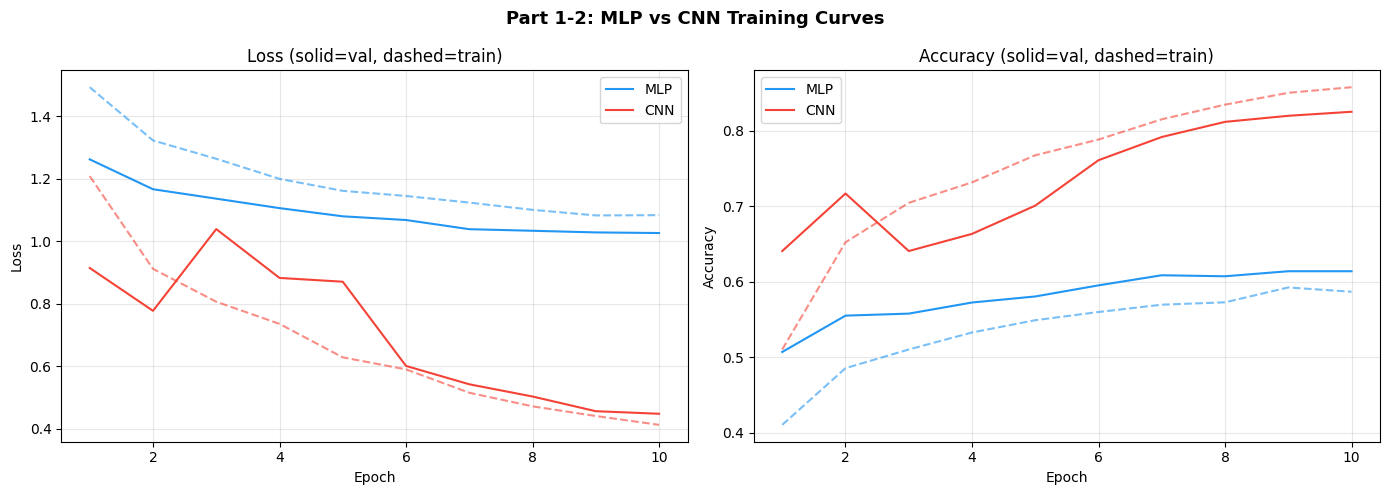

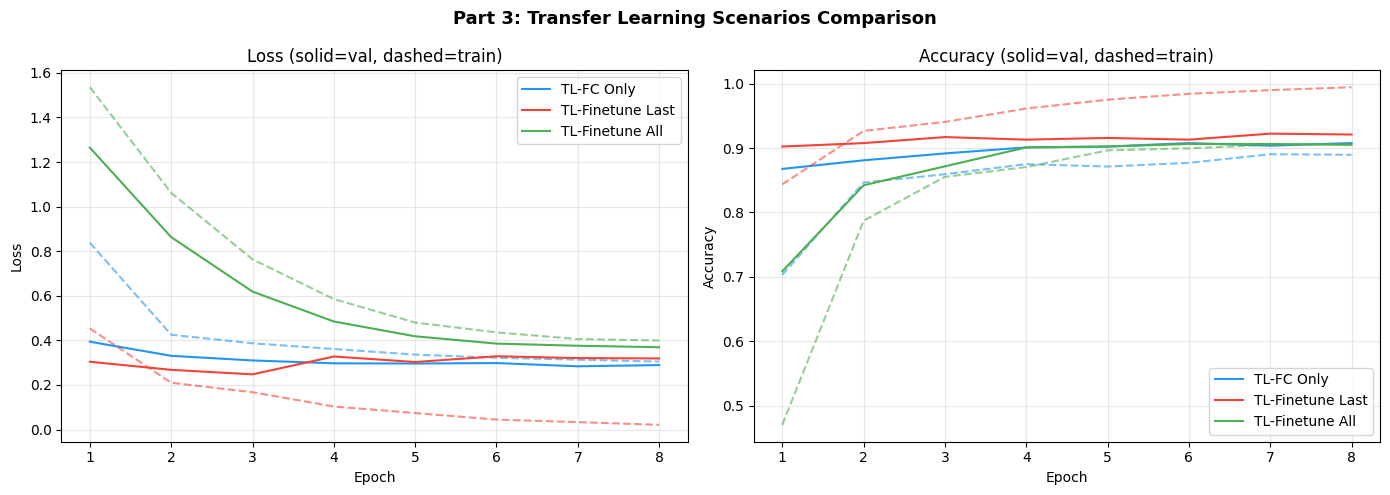

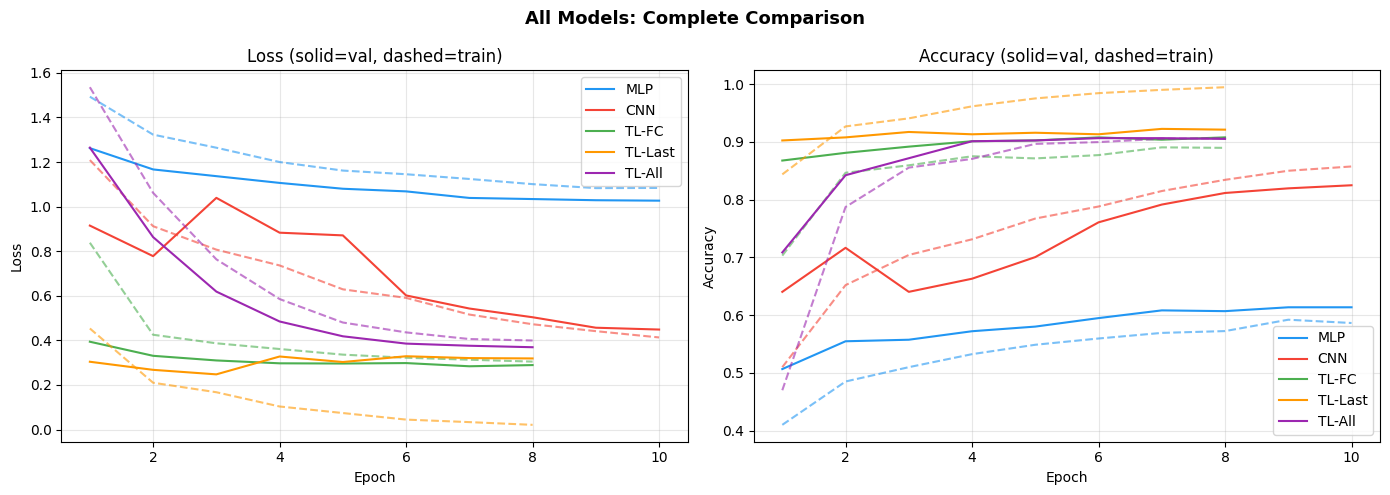

In [19]:
# Plot simple models
plot_history(
    [hist_mlp, hist_cnn],
    ['MLP', 'CNN'],
    title='Part 1-2: MLP vs CNN Training Curves'
)

# Plot transfer learning scenarios
plot_history(
    [hist_fc, hist_last, hist_full],
    ['TL-FC Only', 'TL-Finetune Last', 'TL-Finetune All'],
    title='Part 3: Transfer Learning Scenarios Comparison'
)

# All together
plot_history(
    [hist_mlp, hist_cnn, hist_fc, hist_last, hist_full],
    ['MLP', 'CNN', 'TL-FC', 'TL-Last', 'TL-All'],
    title='All Models: Complete Comparison'
)

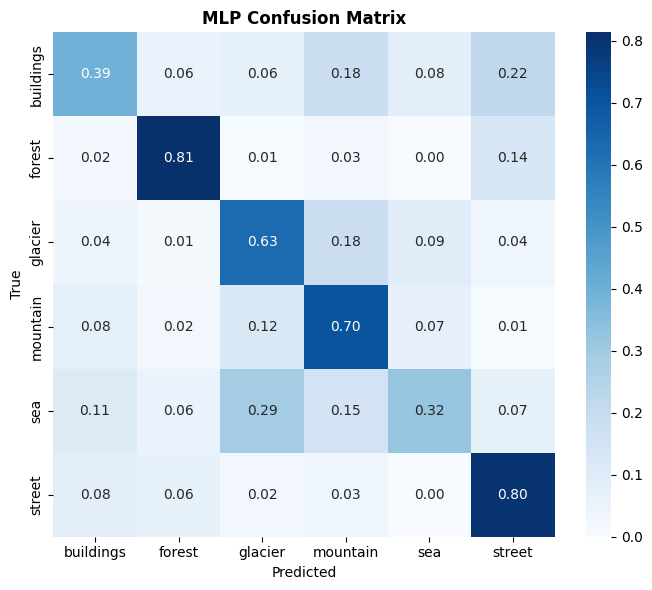

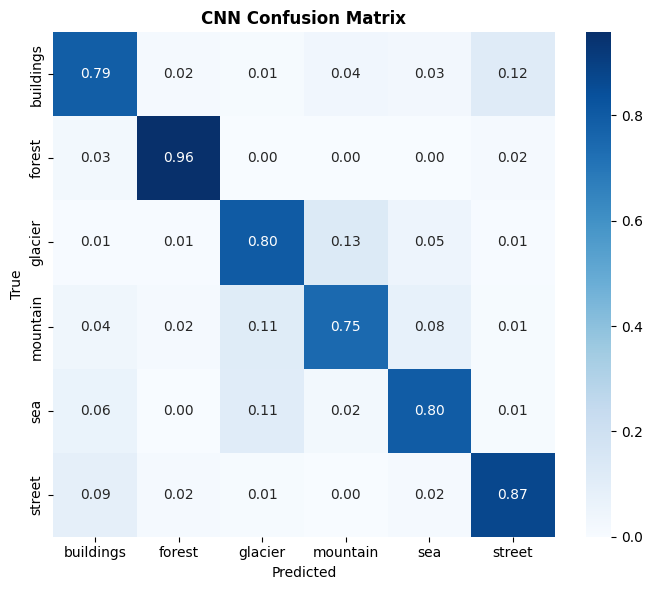

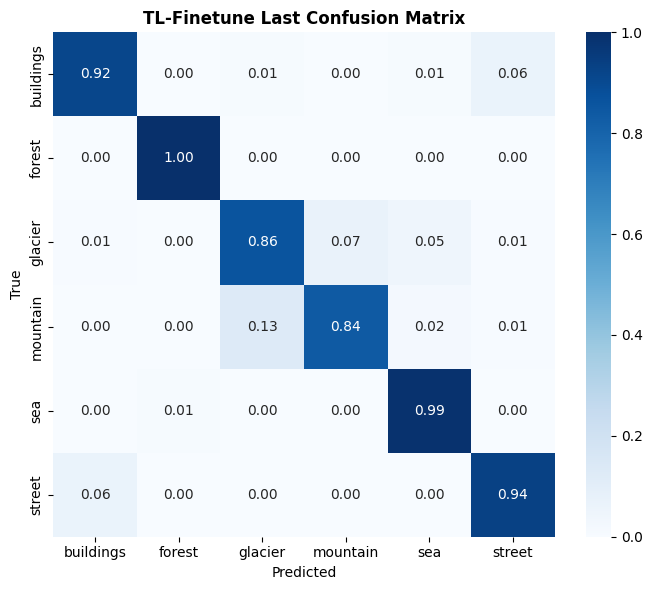

In [20]:
# plotting convusion matrix
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(f'cm_{title[:10].replace(" ","_")}.png', dpi=100)
    plt.show()


plot_confusion(mlp_true,  mlp_preds,  'MLP Confusion Matrix')
plot_confusion(cnn_true,  cnn_preds,  'CNN Confusion Matrix')
plot_confusion(last_true, last_preds, 'TL-Finetune Last Confusion Matrix')

In [21]:
# diso=playing results and summary
results = {
    'MLP':               {'val_acc': mlp_acc,  'history': hist_mlp},
    'CNN':               {'val_acc': cnn_acc,  'history': hist_cnn},
    'TL_FC_Only':        {'val_acc': fc_acc,   'history': hist_fc},
    'TL_Finetune_Last':  {'val_acc': last_acc, 'history': hist_last},
    'TL_Finetune_All':   {'val_acc': full_acc, 'history': hist_full},
}

print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'{"Model":<25} {"Val Acc":>10} {"Best Val Acc":>14}')
print('-' * 55)
for name, data in results.items():
    best = max(data['history']['val_acc'])
    print(f'{name:<25} {data["val_acc"]:>10.4f} {best:>14.4f}')

# Save to JSON
json_results = {}
for name, data in results.items():
    json_results[name] = {
        'final_val_acc': round(data['val_acc'], 4),
        'best_val_acc':  round(max(data['history']['val_acc']), 4),
        'final_val_loss': round(data['history']['val_loss'][-1], 4),
        'train_loss_curve': [round(x, 4) for x in data['history']['train_loss']],
        'val_loss_curve':   [round(x, 4) for x in data['history']['val_loss']],
        'train_acc_curve':  [round(x, 4) for x in data['history']['train_acc']],
        'val_acc_curve':    [round(x, 4) for x in data['history']['val_acc']],
    }

with open('results.json', 'w') as f:
    json.dump(json_results, f, indent=2)

print('\n✅ Results saved to results.json')

FINAL RESULTS SUMMARY
Model                        Val Acc   Best Val Acc
-------------------------------------------------------
MLP                           0.6136         0.6136
CNN                           0.8249         0.8249
TL_FC_Only                    0.9078         0.9078
TL_Finetune_Last              0.9225         0.9225
TL_Finetune_All               0.9064         0.9064

✅ Results saved to results.json


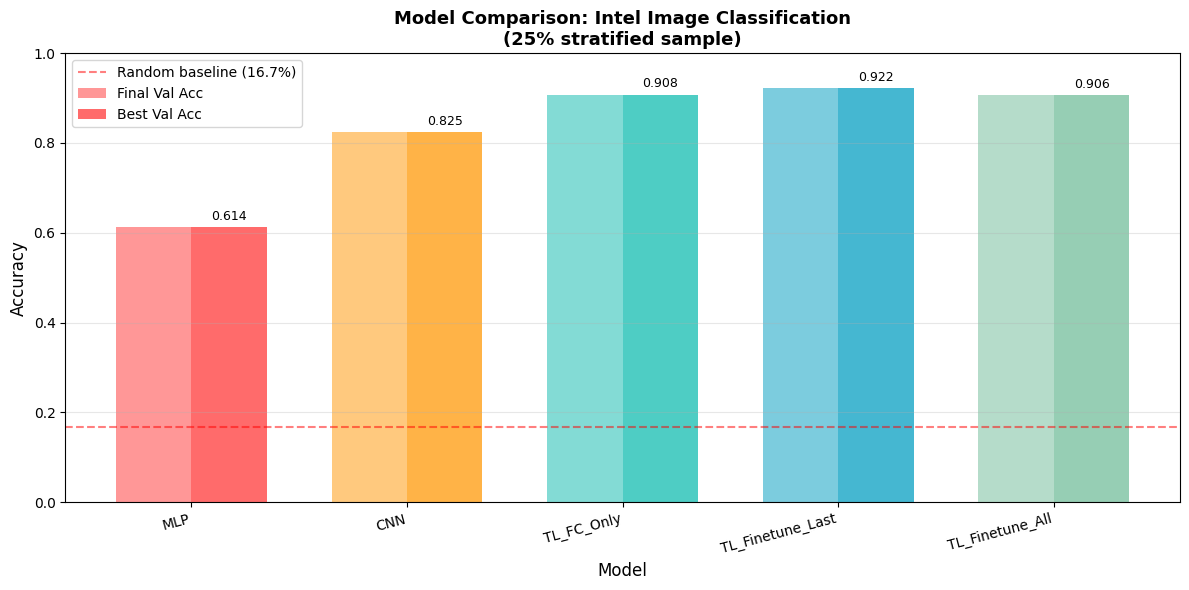

In [22]:
#BAR CHART — Final Model Comparison
model_names  = list(results.keys())
val_accs     = [results[m]['val_acc'] for m in model_names]
best_accs    = [max(results[m]['history']['val_acc']) for m in model_names]

x = np.arange(len(model_names))
width = 0.35
colors_bar = ['#FF6B6B', '#FFB347', '#4ECDC4', '#45B7D1', '#96CEB4']

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, val_accs,  width, label='Final Val Acc',  color=colors_bar, alpha=0.7)
bars2 = ax.bar(x + width/2, best_accs, width, label='Best Val Acc',   color=colors_bar, alpha=1.0)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Comparison: Intel Image Classification\n(25% stratified sample)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.0)
ax.axhline(y=1/6, color='red', linestyle='--', alpha=0.5, label='Random baseline (16.7%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()